# Introduction

This project tackles common sense question answering using the [CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa) dataset. The goal is to train and evaluate two different neural network architectures:

1. A simple classifier using pre-trained word embeddings (fastText)
2. A recurrent neural network (GRU) with word embeddings

This notebook implements both architectures, evaluates their performance, and analyzes the results.

Experiment Tracking: [Weights & Biases - Commonsense QA Models](https://wandb.ai/timon-schmid-hochschule-luzern/hslu-nlp-commonsense_qa?nw=scivmce9vvn)
(*will be mentioned later*)

## Dataset

[CommonsenseQA](https://huggingface.co/datasets/tau/commonsense_qa) is a multiple-choice question answering dataset that requires common sense knowledge to select the correct answer from five choices.

### Data Exploration

To build the model architecutre it is useful to know the token length of the longest question. To make an estimation we take the longest question from the dataset (Hugging Face Data Studio) and split it by spaces to count the items which is an estimate to tokens.

In [24]:
longest_question = """Laura and Bob are a married couple who have begun reaching tentative agreement 
    regarding their sexual incompatibility. They love each other and want to remain together, but 
    have decided that they can see other people to fulfill their needs as long as they are honest 
    about it. Then entire negotiation is being done with a surprising amount of what given the 
    subject matter?"""

print(f'Amount of words of longest question in dataset: {len(longest_question.split())}')

Amount of words of longest question in dataset: 63


# Setup


## Imports

This section contains all the imports that are required in this notebook and gives a brief overview which packages are being used.

In [25]:
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset

from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import word_tokenize

import gensim
import gensim.downloader as api
from huggingface_hub import hf_hub_download

import wandb

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

## Seed

Setting a fixed random seed ensures **reproducibility** of results across runs. We set the seed for NumPy and PyTorch random number generators to ensure that random operations like weight initialization and data shuffling produce the same results each time the notebook is executed.

In [26]:
SEED = 5

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)

## Experiment Tracking

[Weights and Biases](https://wandb.ai/site/) is a machine learning experiment tracking and visualization platform that helps track, compare, and optimize models.

The dashboard is available here: [Weights & Biases - Commonsense QA Models](https://wandb.ai/timon-schmid-hochschule-luzern/hslu-nlp-commonsense_qa?nw=scivmce9vvn)

In [27]:
wandb.login()

True

The `initialize_wandb_run` function configures a new wandb run with metadata about the experiment.

In [28]:
def initialize_wandb_run(
    run_name,
    embedding_type, # Options: word2vec, glove, fastText
    learning_rate,
    batch_size,
    num_epochs,
    rnn_type=None, # Options: lstm, gru
    entity_name="timon-schmid-hochschule-luzern",
    project_name="hslu-nlp-commonsense_qa",):
    
    wandb.init(
        entity=entity_name,
        project=project_name,
        name=run_name,
        config={
            "embedding_type": embedding_type,
            "rnn_architecture": rnn_type,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            
            # Additional configuration details as per project requirements
            "dataset": "tau/commonsense_qa",
            "classifier_layers": 2,
            "activation_function": "ReLU"
        }
    )
    
    # Return the wandb run object for further logging
    return wandb

# Preprocessing

For the Preprocessing we do **tokenization** to make the text suitable for model training.

I chose not to do **lowercasing** to prevent the text from losing any helpful information. A good example is `US` menaing (United States) and `us` as a pronoun.

**Stemming** and **lemmatizing** are not needed as word embeddings like (word2vec, GloVe, fastText) can capture word relationships and handle word variations.

**Stopwords** often carry important grammatical context which is why I decided to keep them.

The dataset from Hugging Face is clean and does not require any **format cleaning**.

As seen in the data analysis the longest question contains around 63 tokens which is still short enough and therefore **truncation** is not required.


## Tokenization

I chose the `NLTK Punkt Tokenizer` as it accurately handles complex sentence structures, recognizes abbreviations, acronyms, and other nuanced punctuation.

In [29]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/timon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

We define a `preprocess_text` function which later on can be used for text preprocessing to make it fit the model input (word embedding)

In [30]:
def preprocess_text(text):
    return word_tokenize(text)

## Data Loading

### Data Split

We use the data split that was mention in the course lecture, because the test set does not contain the answer key.

In [31]:
train_dataset = load_dataset("tau/commonsense_qa", split="train[:-1000]")
validation_dataset = load_dataset("tau/commonsense_qa", split="train[-1000:]")
test_dataset = load_dataset("tau/commonsense_qa", split="validation")

print(f'Train: {len(train_dataset)}, Validation: {len(validation_dataset)}, Test: {len(test_dataset)}')

Train: 8741, Validation: 1000, Test: 1221


## Word Embedding

For the word embedding I chose to use fastText as it can handle out of vocabulary words.

### Fast Text

In [32]:
model_path = hf_hub_download("facebook/fasttext-en-vectors", "model.bin")

fasttext_model = gensim.models.fasttext.load_facebook_model(model_path)
wv = fasttext_model.wv

In [33]:
print(f"Word embeddings vector size: {wv.vector_size}")
print(f"Word embeddings vocab size: {len(wv.index_to_key)}")

Word embeddings vector size: 300
Word embeddings vocab size: 2000000


## Custom Dataset

The custom dataset implementation ensures consistent preprocessing across training, validation, and test sets. It also enables us to use the dataloader from pytorch in the training section easily.

### WordEmbedding Classifier Dataset

It provides a custom `_get_avg_embedding` function that transforms a sequence of tokens (words) into a single fixed-length vector representation by averaging the embedding vectors of each word.

The input feature consists of a concatenation between the question and the possible answers that were previously embedded.

In [35]:
EMBEDDING_DIM = 300
NUM_CLASSES = 5

class CommonsenseQADataset(Dataset):
    def __init__(self, data, fasttext_model):
        self.data = data
        self.fasttext_model = fasttext_model
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        question = item['question']
        choices = [item['choices']['text'][i] for i in range(len(item['choices']['text']))]
        
        # Preprocess question
        question_tokens = word_tokenize(question.lower())
        question_embedding = self._get_avg_embedding(question_tokens)
        
        # Preprocess choices
        choice_embeddings = []
        for choice in choices:
            choice_tokens = word_tokenize(choice.lower())
            choice_embedding = self._get_avg_embedding(choice_tokens)
            choice_embeddings.append(choice_embedding)
        
        # Pad choices to ensure we always have 5 choices
        while len(choice_embeddings) < 5:
            choice_embeddings.append(np.zeros(EMBEDDING_DIM))
        
        # Combine question and choices
        features = np.concatenate([question_embedding] + choice_embeddings)
        
        # Get label (correct answer index)
        label = ord(item['answerKey']) - ord('A')
        
        return torch.FloatTensor(features), torch.tensor(label, dtype=torch.long)
    
    def _get_avg_embedding(self, tokens):
        if not tokens:
            return np.zeros(EMBEDDING_DIM)
        
        embeddings = []
        for token in tokens:
            try:
                # Get embedding from word vectors
                embeddings.append(self.fasttext_model.wv[token])
            except KeyError:
                # For out-of-vocabulary words, use zero vector
                embeddings.append(np.zeros(EMBEDDING_DIM))
        
        return np.mean(embeddings, axis=0)
    

### RNN Classifier Dataset

Unlike the previous implementation that used averaged embeddings, this version preserves sequence information:

- Creates a dataset that maintains token sequence order for both questions and answer choices
- Converts text to word embeddings while respecting sequence length (max 64 tokens)
- Provides padded/truncated sequences of consistent length for batch processing
- Includes sequence length information for packed RNN processing
- Returns a dictionary with all necessary features for training a sequence model

In [36]:
class CommonsenseQARNNDataset(Dataset):
    def __init__(self, data, word_vectors, max_seq_length=64):
        self.data = data
        self.word_vectors = word_vectors
        self.max_seq_length = max_seq_length
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        question = item['question']
        choices = [item['choices']['text'][i] for i in range(len(item['choices']['text']))]
        
        # Process question
        question_tokens = word_tokenize(question.lower())[:self.max_seq_length]
        question_embeddings = []
        for token in question_tokens:
            try:
                question_embeddings.append(self.word_vectors[token])
            except KeyError:
                question_embeddings.append(np.zeros(EMBEDDING_DIM))
        
        # Process each choice
        choice_features = []
        for choice in choices:
            choice_tokens = word_tokenize(choice.lower())[:self.max_seq_length]
            choice_embeddings = []
            for token in choice_tokens:
                try:
                    choice_embeddings.append(self.word_vectors[token])
                except KeyError:
                    choice_embeddings.append(np.zeros(EMBEDDING_DIM))
            
            # Pad or truncate to fixed length
            padded_choice = self._pad_sequence(choice_embeddings)
            choice_features.append(padded_choice)
        
        # Pad choices to ensure we always have 5
        while len(choice_features) < 5:
            choice_features.append(np.zeros((self.max_seq_length, EMBEDDING_DIM)))
        
        # Pad question to fixed length
        padded_question = self._pad_sequence(question_embeddings)
        
        # Get true lengths for packing
        question_length = min(len(question_tokens), self.max_seq_length)
        choice_lengths = []
        for i, choice in enumerate(choices):
            choice_tokens = word_tokenize(choice.lower())
            choice_lengths.append(min(len(choice_tokens), self.max_seq_length))
        
        # Pad choice lengths to 5
        while len(choice_lengths) < 5:
            choice_lengths.append(0)
        
        # Get label (correct answer index)
        label = ord(item['answerKey']) - ord('A')
        
        # Convert lists to numpy arrays first to avoid the warning
        choice_features_np = np.array(choice_features)
        
        return {
            'question_embeds': torch.FloatTensor(padded_question),
            'question_length': question_length,
            'choice_embeds': torch.FloatTensor(choice_features_np),
            'choice_lengths': torch.LongTensor(choice_lengths),
            'label': torch.tensor(label, dtype=torch.long)
        }
    
    def _pad_sequence(self, sequence):
        padded_seq = np.zeros((self.max_seq_length, EMBEDDING_DIM))
        if len(sequence) > 0:
            padded_seq[:min(len(sequence), self.max_seq_length)] = sequence[:self.max_seq_length]
        return padded_seq

# Models

## WordEmbedding Classifier

A simple neural network classifier that processes word embedding features for commonsense QA:

Two-layer feed-forward neural network architecture

Takes concatenated word embeddings as **input** (question + choices)

Applies dropout regularization to prevent overfitting

Transforms input through a hidden layer with ReLU activation

**Outputs** logits corresponding to each potential answer choice

In [37]:
class WordEmbeddingClassifier(nn.Module):
    def __init__(self, input_dim, hidden_size, num_classes, dropout_rate):
        super(WordEmbeddingClassifier, self).__init__()
        
        self.dropout = nn.Dropout(dropout_rate)
        
        self.fc1 = nn.Linear(input_dim, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.dropout(self.relu(out))
        out = self.fc2(out)
        return out

## RNN with Classifier

This model implements a bidirectional GRU-based neural network for the commonsense QA task:

Uses separate GRU encoders to process both questions and answer choices

Maintains sequence information through packed sequences to handle variable lengths

Implements bidirectional processing to capture context from both directions

Combines question and choice representations (all 5 choices) into a single feature vector

Passes the combined representations through a classifier to predict the correct answer

In [38]:
class GRUClassifier(nn.Module):
    def __init__(self, embedding_dim, hidden_size, num_layers, dropout_rate):
        super(GRUClassifier, self).__init__()
        
        self.embedding_dim = embedding_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # GRU layers for question and choices
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Classifier layers
        self.dropout = nn.Dropout(dropout_rate)
        self.fc1 = nn.Linear(hidden_size * 2 * 6, hidden_size) # 2 for bidirectional, 6 for question + 5 choices
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, NUM_CLASSES)
        
    def forward(self, batch):
        # Process question
        question_embeds = batch['question_embeds']  # [batch_size, seq_len, embedding_dim]
        question_lengths = batch['question_length']  # [batch_size]
        
        # Pack question sequences
        packed_question = nn.utils.rnn.pack_padded_sequence(
            question_embeds, 
            question_lengths.cpu(), 
            batch_first=True, 
            enforce_sorted=False
        )
        
        # Process question through GRU
        _, question_hidden = self.gru(packed_question)  # [num_layers * num_directions, batch_size, hidden_size]
        
        # Get the final hidden state (concatenate forward and backward for bidirectional)
        question_hidden = torch.cat((question_hidden[-2,:,:], question_hidden[-1,:,:]), dim=1)  # [batch_size, hidden_size*2]
        
        # Process each choice
        choice_embeds = batch['choice_embeds']  # [batch_size, 5, seq_len, embedding_dim]
        choice_lengths = batch['choice_lengths']  # [batch_size, 5]
        
        batch_size = choice_embeds.size(0)
        choice_hiddens = []
        
        for i in range(5):  # For each of the 5 choices
            # Extract this choice data
            this_choice_embeds = choice_embeds[:, i, :, :]  # [batch_size, seq_len, embedding_dim]
            this_choice_lens = choice_lengths[:, i]  # [batch_size]
            
            # Skip empty choices (pad with zeros later)
            valid_indices = this_choice_lens > 0
            if not valid_indices.any():
                # If all choices are invalid (length 0), use zeros
                choice_hiddens.append(torch.zeros(batch_size, self.hidden_size * 2, device=question_hidden.device))
                continue
            
            # Pack valid choices
            valid_embeds = this_choice_embeds[valid_indices]
            valid_lens = this_choice_lens[valid_indices]
            
            packed_choice = nn.utils.rnn.pack_padded_sequence(
                valid_embeds, 
                valid_lens.cpu(), 
                batch_first=True, 
                enforce_sorted=False
            )
            
            # Process through GRU
            _, choice_hidden = self.gru(packed_choice)
            
            # Get final hidden state
            choice_hidden = torch.cat((choice_hidden[-2,:,:], choice_hidden[-1,:,:]), dim=1)  # [valid_batch_size, hidden_size*2]
            
            # Create full batch tensor with zeros for invalid choices
            full_hidden = torch.zeros(batch_size, self.hidden_size * 2, device=question_hidden.device)
            full_hidden[valid_indices] = choice_hidden
            
            choice_hiddens.append(full_hidden)
        
        # Combine question and all choices
        combined = torch.cat([question_hidden] + choice_hiddens, dim=1)  # [batch_size, (1+5)*hidden_size*2]
        
        # Pass through classifier
        combined = self.dropout(combined)
        out = self.fc1(combined)
        out = self.dropout(self.relu(out))
        out = self.fc2(out)
        
        return out
    

# Training & Evaluation

## WordEmbedding Classifier

The following section implements the training loop and evaluation function for the commonsense QA model. 

The training function handles the complete training pipeline including gradient updates, learning rate scheduling, model checkpointing, and performance tracking with Weights & Biases. 

It saves both epoch-specific **checkpoints** and the best-performing model based on validation accuracy. 

The evaluation function calculates loss and accuracy metrics on a validation set in a separate function that disables gradient computation for efficiency. 

Both functions include progress tracking with tqdm and device-agnostic computation supporting both CPU and MPS (Apple Silicon).

In [39]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler, model_name, 
         patience=5, min_delta=0.001):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model.to(device)
    
    best_val_acc = 0
    best_val_loss = float('inf')
    training_history = []
    
    # Early stopping variables
    counter = 0
    early_stop = False
    
    for epoch in range(num_epochs):
        if early_stop:
            print(f"Early stopping triggered after {epoch} epochs!")
            break
            
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # Train for one epoch
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for features, labels in tqdm(train_loader):
            optimizer.zero_grad()
            
            features, labels = features.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            # Backward and optimize
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # clip gradients to prevent exploding gradients
            
            optimizer.step()
            if scheduler:
                scheduler.step()
            
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # Evaluate on validation set
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        # Log metrics to W&B
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        # Store history
        epoch_results = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        }
        training_history.append(epoch_results)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Save checkpoint for every epoch
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        }
        torch.save(checkpoint, f'checkpoints/epoch_{epoch+1}.pt')
        print(f"Checkpoint saved for epoch {epoch+1}")
        
        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_acc': train_acc,
                'val_acc': val_acc,
                'best_val_acc': best_val_acc
            }, f'checkpoints/best_{model_name}_model.pt')
            print(f"New best model saved! Validation accuracy: {val_acc:.4f}")
        
        # Early stopping check based on validation loss
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            counter = 0
        else:
            counter += 1
            print(f"Early stopping counter: {counter}/{patience}")
            
        if counter >= patience:
            print(f"Early stopping triggered! No improvement in validation loss for {patience} epochs.")
            early_stop = True
    
    return training_history, best_val_acc


# Evaluation function (unchanged)
def evaluate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for features, labels in tqdm(val_loader):
            features, labels = features.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = total_loss / len(val_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

### Training Run

This section defines the hyperparameters and sets up the training pipeline for the fastText-based commonsense QA model. Key configuration elements include:

The model uses a word embedding classifier with fastText embeddings as the base representation. It processes concatenated embeddings from both the question and all five answer choices.

Hyperparameters include a moderate learning rate (1e-3), relatively large batch size (128), and dropout regularization (0.3) to prevent overfitting during the 30 training epochs.

For optimization, the code employs:
- `CrossEntropyLoss` as the criterion, appropriate for multi-class classification
- `AdamW` optimizer with weight decay (1e-4) for improved generalization
- `OneCycleLR` scheduler that dynamically adjusts the learning rate throughout training with a peak at 2e-3

The training progress is monitored using Weights & Biases for experiment tracking, with model architecture and hyperparameters logged for reproducibility. Dataset sizes are printed to provide context for the training process.

In [46]:
# Model parameters
embedding_type = "fastText"
learning_rate = 1e-3
batch_size = 256
num_epochs = 50
hidden_size = 128
dropout = 0.2
model_name = 'fastText-emb-classifier'
run_name = f'{model_name}-{time.strftime("%Y%m%d-%H%M%S")}'

# Calculate input dimension: question embedding + 5 choice embeddings
input_dim = EMBEDDING_DIM * 6  # 1 question + 5 choices
    
# Initialize wandb with your custom function
initialize_wandb_run(
    run_name=run_name,
    embedding_type=embedding_type,
    learning_rate=learning_rate,
    batch_size=batch_size,
    num_epochs=num_epochs
)
    
# Create datasets
train_data = CommonsenseQADataset(train_dataset, fasttext_model)
val_data = CommonsenseQADataset(validation_dataset, fasttext_model)

print(f"Train dataset size: {len(train_data)}")
print(f"Validation dataset size: {len(val_data)}")
    
# Create data loaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
    
# Initialize model
emb_model = WordEmbeddingClassifier(input_dim, hidden_size, NUM_CLASSES, dropout)
    
# Log model architecture to wandb
wandb.config.update({
    "embedding_dim": wv.vector_size,
    "hidden_size": hidden_size,
    "model_type": "WordEmbeddingClassifier"
})
wandb.watch(emb_model)
    
    
# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(emb_model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=2e-3, steps_per_epoch=len(train_loader), epochs=num_epochs+1)

# Train the model
training_history, best_val_acc = train(emb_model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler, model_name)

print(f"Best validation accuracy: {best_val_acc:.4f}")
    
wandb.finish()

Train dataset size: 8741
Validation dataset size: 1000
Epoch 1/50


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 1.6102, Train Acc: 0.2041, Val Loss: 1.6100, Val Acc: 0.1910
Checkpoint saved for epoch 1
New best model saved! Validation accuracy: 0.1910
Epoch 2/50


  0%|          | 0/35 [00:00<?, ?it/s]

...

Train Loss: 1.5096, Train Acc: 0.3564, Val Loss: 1.6411, Val Acc: 0.2060
Checkpoint saved for epoch 8
Early stopping counter: 4/5
Epoch 9/50


  0%|          | 0/35 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 1.4745, Train Acc: 0.3749, Val Loss: 1.6635, Val Acc: 0.2220
Checkpoint saved for epoch 9
Early stopping counter: 5/5
Early stopping triggered! No improvement in validation loss for 5 epochs.
Early stopping triggered after 9 epochs!
Best validation accuracy: 0.2250


epoch,▁▂▃▄▅▅▆▇█
train_acc,▁▂▃▅▆▅▆▇█
train_loss,███▇▇▆▅▃▁
val_acc,▁▁▅▅▇█▆▄▇
val_loss,▁▁▁▁▁▁▃▅█
epoch,9
train_acc,0.3749
train_loss,1.47448
val_acc,0.222
val_loss,1.66352


## RNN Classifier

This code implements specialized training and evaluation functions for the sequence-based GRU model. Unlike the embedding classifier's training function, this version handles dictionary-based batches rather than simple tensor pairs. 

The training procedure otherwise follows a similar pattern to the embedding classifier, with gradient clipping, learning rate scheduling, and performance tracking. 

Both functions maintain the same checkpoint saving strategy and Weights & Biases integration, but are tailored to work with the more complex data structures required by sequential models.

In [15]:
def train_rnn(model, train_loader, val_loader, criterion, optimizer, num_epochs, scheduler, model_name):
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
    model.to(device)
    
    best_val_acc = 0
    training_history = []
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        
        # Train for one epoch
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for batch in tqdm(train_loader):
            optimizer.zero_grad()
            
            # Move batch to device
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch[k] = v.to(device)
            
            # Forward pass
            outputs = model(batch)
            loss = criterion(outputs, batch['label'])
            
            # Backward and optimize
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # clip gradients to prevent exploding gradients
            
            optimizer.step()
            if scheduler:
                scheduler.step()
            
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == batch['label']).sum().item()
            total += batch['label'].size(0)
        
        train_loss = total_loss / len(train_loader)
        train_acc = correct / total
        
        # Evaluate on validation set
        val_loss, val_acc = evaluate_rnn(model, val_loader, criterion, device)
        
        # Log metrics to W&B
        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        })
        
        # Store history
        epoch_results = {
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_loss': val_loss,
            'val_acc': val_acc
        }
        training_history.append(epoch_results)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Save checkpoint for every epoch
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        }
        torch.save(checkpoint, f'checkpoints/rnn_epoch_{epoch+1}.pt')
        print(f"Checkpoint saved for epoch {epoch+1}")
        
        # Save the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_acc': train_acc,
                'val_acc': val_acc,
                'best_val_acc': best_val_acc
            }, f'checkpoints/best_{model_name}_model.pt')
            print(f"New best model saved! Validation accuracy: {val_acc:.4f}")
    
    return training_history, best_val_acc


# Evaluation function for RNN model
def evaluate_rnn(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader):
            # Move batch to device
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch[k] = v.to(device)
            
            # Forward pass
            outputs = model(batch)
            loss = criterion(outputs, batch['label'])
            
            total_loss += loss.item()
            
            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == batch['label']).sum().item()
            total += batch['label'].size(0)
    
    epoch_loss = total_loss / len(val_loader)
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc


### RNN Training Run 

The training configuration uses fastText embeddings with a bidirectional GRU architecture, optimized for sequence processing.

The hyperparameters reflect the needs of sequence models: a smaller batch size (32) to accommodate longer sequences, a moderate learning rate (5e-4), and a more complex model with 2 stacked GRU layers. The hidden size is set to 128 dimensions with dropout (0.3) applied for regularization during the 20 training epochs.

For optimization, the code employs:
- `CrossEntropyLoss` criterion for the multi-class classification problem
- `AdamW` optimizer with weight decay (1e-4) to prevent overfitting
- `OneCycleLR` scheduler with a more aggressive peak learning rate (5e-3, 10x the base rate)

The model architecture is more complex, employing bidirectional GRUs to capture contextual information from both directions.

In [16]:
# Model parameters
embedding_type = "fastText"
rnn_type = "gru"
learning_rate = 5e-4
batch_size = 32
num_epochs = 20
hidden_size = 128
num_layers = 2
dropout_rate = 0.3
model_name = 'fastText-gru-classifier'
run_name = f'{model_name}-{time.strftime("%Y%m%d-%H%M%S")}'
    
# Initialize wandb with your custom function
initialize_wandb_run(
    run_name=run_name,
    embedding_type=embedding_type,
    learning_rate=learning_rate,
    batch_size=batch_size,
    num_epochs=num_epochs,
    rnn_type=rnn_type
)
    
# Create datasets
train_data = CommonsenseQARNNDataset(train_dataset, wv)
val_data = CommonsenseQARNNDataset(validation_dataset, wv)
    
print(f"Train dataset size: {len(train_data)}")
print(f"Validation dataset size: {len(val_data)}")
    
# Create data loaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size)
    
# Initialize GRU model
gru_model = GRUClassifier(EMBEDDING_DIM, hidden_size, num_layers, dropout_rate)
    
# Log model architecture to wandb
wandb.config.update({
    "embedding_dim": EMBEDDING_DIM,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "model_type": "GRUClassifier"
})
wandb.watch(gru_model)
    
# Define optimizer and loss function
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(gru_model.parameters(), lr=learning_rate, weight_decay=1e-4)
total_steps = len(train_loader) * num_epochs
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=learning_rate*10, 
    steps_per_epoch=len(train_loader), 
    epochs=num_epochs
)
    
# Train the model
training_history, best_val_acc = train_rnn(
    gru_model, 
    train_loader, 
    val_loader, 
    criterion, 
    optimizer, 
    num_epochs, 
    scheduler, 
    model_name
)
    
print(f"Best validation accuracy: {best_val_acc:.4f}")
    
wandb.finish()

Train dataset size: 8741
Validation dataset size: 1000
Epoch 1/20


  0%|          | 0/274 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 1.6104, Train Acc: 0.1996, Val Loss: 1.6102, Val Acc: 0.2130
Checkpoint saved for epoch 1
New best model saved! Validation accuracy: 0.2130
Epoch 2/20


  0%|          | 0/274 [00:00<?, ?it/s]

...

Train Loss: 1.4163, Train Acc: 0.3480, Val Loss: 1.9088, Val Acc: 0.2030
Checkpoint saved for epoch 19
Epoch 20/20


  0%|          | 0/274 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Train Loss: 1.4140, Train Acc: 0.3480, Val Loss: 1.9114, Val Acc: 0.2010
Checkpoint saved for epoch 20
Best validation accuracy: 0.2280


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train_acc,▁▁▂▂▂▂▁▁▁▂▂▃▃▄▅▆▆▇██
train_loss,█████████▇▇▇▆▆▅▄▃▂▁▁
val_acc,▅▆▃▆▄█▄▇█▄▂▁▄▅▄▄▅▄▄▃
val_loss,▁▁▁▁▁▁▁▁▁▁▁▂▁▂▄▄▇▇██
epoch,20
train_acc,0.34802
train_loss,1.41396
val_acc,0.201
val_loss,1.91138


# Interpretation

Even though both models indicate for overfitting we do compare their performances on the test set.

First, we have to load the test data for both dataset implementations.

In [48]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Create test datasets for both models
test_emb_data = CommonsenseQADataset(test_dataset, fasttext_model)
test_rnn_data = CommonsenseQARNNDataset(test_dataset, wv)

# Create test dataloaders
test_emb_loader = DataLoader(test_emb_data, batch_size=batch_size)
test_rnn_loader = DataLoader(test_rnn_data, batch_size=batch_size)

Now we can load the best models from the checkpointing.

In [49]:
emb_model_path = 'checkpoints/best_fastText-emb-classifier_model.pt'
emb_model.load_state_dict(torch.load(emb_model_path)["model_state_dict"])
emb_model.to(device)
emb_model.eval()

gru_model_path = 'checkpoints/best_fastText-gru-classifier_model.pt'
gru_model.load_state_dict(torch.load(gru_model_path)["model_state_dict"])
gru_model.to(device)
gru_model.eval()

GRUClassifier(
  (gru): GRU(300, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1536, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=5, bias=True)
)

In order to evaluate their performances we need to provide the output of both models with similar structure

In [50]:
def get_predictions_emb(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in data_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

def get_predictions_rnn(model, data_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in data_loader:
            # Move batch to device
            for k, v in batch.items():
                if isinstance(v, torch.Tensor):
                    batch[k] = v.to(device)
            
            outputs = model(batch)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['label'].cpu().numpy())
    
    return np.array(all_preds), np.array(all_labels)

## Confusion Matrix

Confusion matrices are visualized side-by-side using seaborn heatmaps with labeled axes representing answer choices (A-E)

This comparative analysis reveals how each model architecture handles the commonsense QA task.

Getting predictions for Word Embedding model...
Getting predictions for GRU model...


/Users/timon/.pyenv/versions/3.9.21/envs/nlp/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/timon/.pyenv/versions/3.9.21/envs/nlp/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/timon/.pyenv/versions/3.9.21/envs/nlp/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Word Embedding Model - Test Accuracy: 0.2064
GRU Model - Test Accuracy: 0.2113


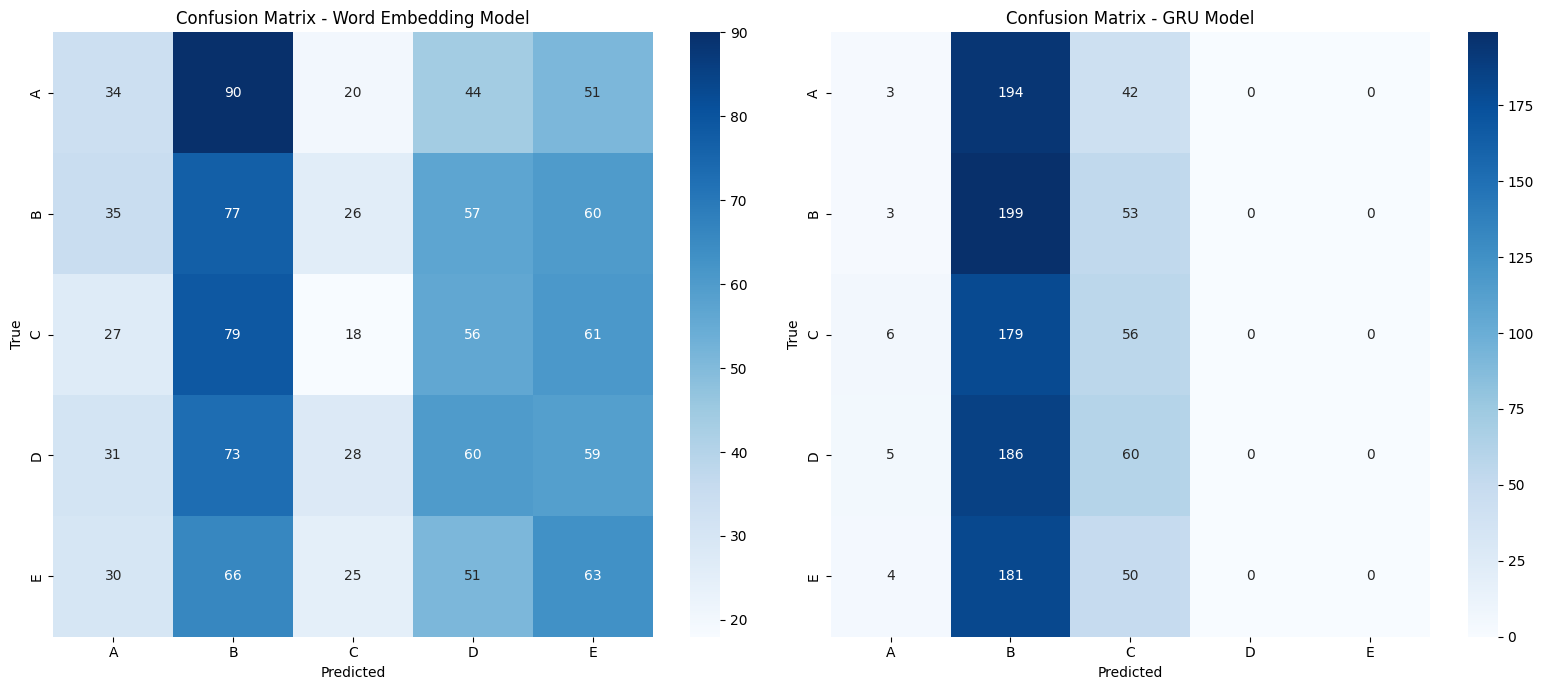

In [51]:
print("Getting predictions for Word Embedding model...")
emb_preds, emb_labels = get_predictions_emb(emb_model, test_emb_loader, device)

print("Getting predictions for GRU model...")
rnn_preds, rnn_labels = get_predictions_rnn(gru_model, test_rnn_loader, device)

# Calculate evaluation metrics
def calculate_metrics(preds, labels):
    # Calculate accuracy
    accuracy = np.mean(preds == labels)
    # Create confusion matrix
    cm = confusion_matrix(labels, preds)
    # Create classification report
    report = classification_report(labels, preds, output_dict=True)
    return accuracy, cm, report

# Calculate metrics for both models
emb_accuracy, emb_cm, emb_report = calculate_metrics(emb_preds, emb_labels)
rnn_accuracy, rnn_cm, rnn_report = calculate_metrics(rnn_preds, rnn_labels)

print(f"Word Embedding Model - Test Accuracy: {emb_accuracy:.4f}")
print(f"GRU Model - Test Accuracy: {rnn_accuracy:.4f}")

# Plot confusion matrices
plt.figure(figsize=(16, 7))

# Plot confusion matrix for Word Embedding model
plt.subplot(1, 2, 1)
sns.heatmap(emb_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['A', 'B', 'C', 'D', 'E'],
            yticklabels=['A', 'B', 'C', 'D', 'E'])
plt.title('Confusion Matrix - Word Embedding Model')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot confusion matrix for GRU model
plt.subplot(1, 2, 2)
sns.heatmap(rnn_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['A', 'B', 'C', 'D', 'E'],
            yticklabels=['A', 'B', 'C', 'D', 'E'])
plt.title('Confusion Matrix - GRU Model')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

The generated confusion matrices shows that both models tend to choose answer B over the others.

Another interesting fact is that the GRU model never chose option D or E which both could be an indication for overfitting.

## Results

Due to the bad accuracy of:

- Word Embedding Classifier: 0.2023
- GRU Model: 0.2113

I decided not to do any error analysis in the results but rather focus more on what could be improved in the data preprocessing, architecture or training process to reduce the severe overfitting.

# Used Tools

- **Github Copilot** for code completion integrated in Visual Studio Code
- **Claude AI** to challenge different architectures